### Master of Applied Artificial Intelligence

**Course: TC5035 - Proyecto Integrador**

<img src="https://github.com/Medicenchapin/Proyecto-Integrador/blob/main/assets/logo.png?raw=1" alt="Image Alt Text" width="500"/>


**Exploratory Data Analysis**

Tutor: Dr. Horario Martinez Alfaro


Team members:
* Ignacio Jose Aguilar Garcia - A00819762
* Alejandro Calderon Aguilar - A01795353
* Ricardo Mar Cupido - A01795394

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_parquet("../data/campaign_candidates_final.parquet")
df.head()

,state_name,previous_classification,previous_calls,client_age,network_age_years,banking,arpu_90_days,minutes_in,validity_average,average_performance,...,plan_postpaid,sn_banking,digital_index_mean,connected_days,charged_days,apps_days,music_gb,proba,sample_idx,drivers
0,GUATEMALA,NEW CLIENT,0,28.0,3.90,1,214.18,27.93,20.23,0.46,...,0.67,1.00,0.00,91,91,0,5.946,0.699237,0,"[{'feature': 'contacts', 'impact': -0.58204424..."
1,GUATEMALA,NEW CLIENT,0,19.0,0.66,0,92.58,48.77,3.14,0.61,...,0.75,1.00,0.00,76,55,4,0.031,0.781733,10,"[{'feature': 'contacts', 'impact': -0.43256592..."
2,SAN MARCOS,NEW CLIENT,0,20.0,0.34,1,175.49,83.58,4.00,0.25,...,0.12,0.56,0.00,91,59,30,0.000,0.641149,12,"[{'feature': 'client_age', 'impact': 0.4716295..."
3,SAN MARCOS,NEW CLIENT,0,NaN,1.90,1,97.54,51.89,8.36,0.77,...,0.54,0.38,0.29,90,77,11,0.000,0.690091,26,"[{'feature': 'plan_postpaid', 'impact': 0.5216..."
4,SAN MARCOS,NOT EFFECTIVE,2,31.0,5.87,1,102.25,78.93,15.00,0.69,...,0.24,0.30,0.00,89,64,22,0.000,0.733312,37,"[{'feature': 'contacts', 'impact': 0.383831799..."


In [3]:
df['drivers'][0]

array([{'feature': 'contacts', 'impact': -0.582044243812561, 'ohe_category': None, 'raw_feature': 'contacts', 'raw_value': '8', 'value': -1.8448108052715728},
       {'feature': 'music_gb', 'impact': 0.31890058517456055, 'ohe_category': None, 'raw_feature': 'music_gb', 'raw_value': '5.946', 'value': 5.946},
       {'feature': 'plan_postpaid', 'impact': 0.3081912696361542, 'ohe_category': None, 'raw_feature': 'plan_postpaid', 'raw_value': '0.6699999999999999', 'value': 1.869873907209015},
       {'feature': 'client_age', 'impact': 0.18900930881500244, 'ohe_category': None, 'raw_feature': 'client_age', 'raw_value': '28.0', 'value': -1.1497417570435924},
       {'feature': 'average_performance', 'impact': 0.17730332911014557, 'ohe_category': None, 'raw_feature': 'average_performance', 'raw_value': '0.4599999999999999', 'value': -1.2696643851806635}],
      dtype=object)

In [10]:
df.shape

(18303, 23)

<Axes: ylabel='Frequency'>

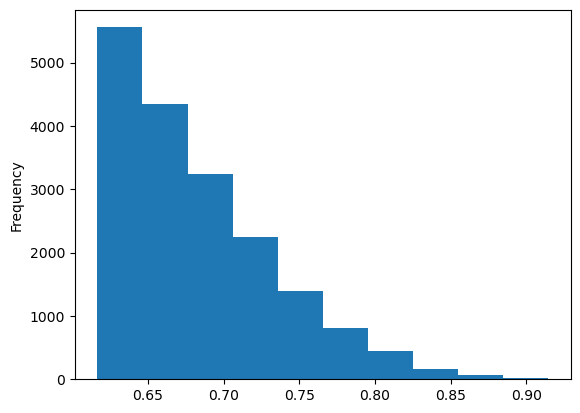

In [11]:
df.proba.plot(kind='hist')

In [16]:
df.drivers[0]

array([{'feature': 'contacts', 'impact': -0.5481446981430054, 'value': -1.8658520907135028},
       {'feature': 'music_gb', 'impact': 0.33521634340286255, 'value': 5.946},
       {'feature': 'plan_postpaid', 'impact': 0.3317587077617645, 'value': 1.869873907209015},
       {'feature': 'average_performance', 'impact': 0.19427262246608734, 'value': -1.2475054798420082},
       {'feature': 'sn_banking', 'impact': 0.1708623766899109, 'value': 2.3300698473697152}],
      dtype=object)

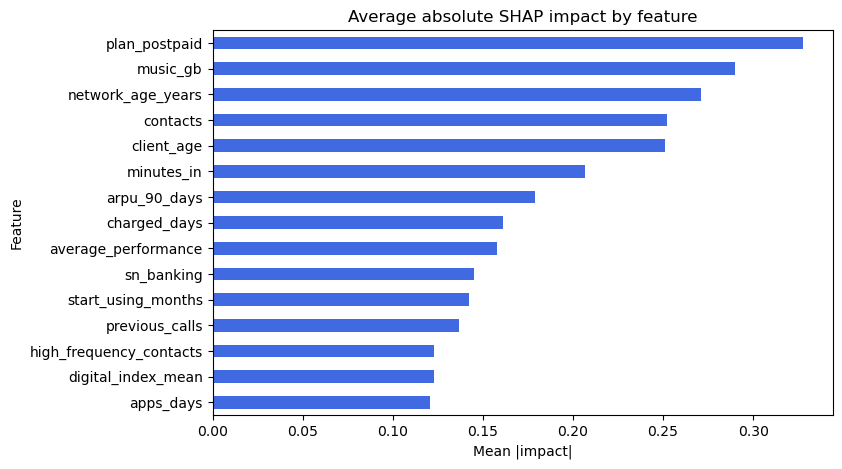

In [9]:
# Extrae todos los impactos en un solo DataFrame
drivers_expanded = (
    df["drivers"]
    .explode()                                # una fila por driver
    .dropna()
    .apply(pd.Series)                         # convierte dict -> columnas
)

# drivers_expanded ahora tiene columnas: feature, value, impact
drivers_expanded["abs_impact"] = drivers_expanded["impact"].abs()

# Agrega el impacto medio por feature
feature_importance = (
    drivers_expanded
    .groupby("feature")["abs_impact"]
    .mean()
    .sort_values(ascending=False)
)

# Plot
plt.figure(figsize=(8,5))
feature_importance.head(15).plot(kind="barh", color="royalblue")
plt.title("Average absolute SHAP impact by feature")
plt.xlabel("Mean |impact|")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable, get_cmap

def plot_beeswarm_from_drivers(df, top=15):
    """
    Custom SHAP-style beeswarm plot using the 'drivers' column in df.
    Each driver is a dict with 'feature', 'value', and 'impact'.
    """
    drivers = df["drivers"].explode().dropna().apply(pd.Series)
    if drivers.empty:
        print("⚠️ No driver data found.")
        return

    # Calcular top features por impacto absoluto promedio
    order = (
        drivers.groupby("feature")["impact"]
        .apply(lambda s: s.abs().mean())
        .sort_values(ascending=False)
        .head(top)
        .index
    )

    # Filtrar y reordenar
    plot_df = drivers[drivers["feature"].isin(order)].copy()
    plot_df["feature"] = pd.Categorical(plot_df["feature"], categories=order, ordered=True)

    # Colores según valor
    vmin, vmax = np.percentile(plot_df["value"], [5, 95])
    norm = Normalize(vmin=vmin, vmax=vmax)
    cmap = get_cmap("coolwarm")

    # Crear figura
    fig, ax = plt.subplots(figsize=(9, 6))
    sc = ax.scatter(
        plot_df["impact"],
        plot_df["feature"],
        c=cmap(norm(plot_df["value"].astype(float))),
        s=10,
        alpha=0.7
    )

    # Línea central y etiquetas
    ax.axvline(0, color="gray", lw=1)
    ax.set_xlabel("SHAP impact (±)")
    ax.set_ylabel("Feature (Top by mean |impact|)")
    ax.set_title("Custom SHAP-style Beeswarm (from drivers)")

    # Barra de color (fíjate en el uso de fig.colorbar con mappable=sc)
    cbar = fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=ax)
    cbar.set_label("Feature value (scaled)")

    plt.tight_layout()
    plt.show()


/var/folders/dd/h6ysp6hd74s6ypbck34s5gym0000gn/T/ipykernel_94262/842296108.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("coolwarm")


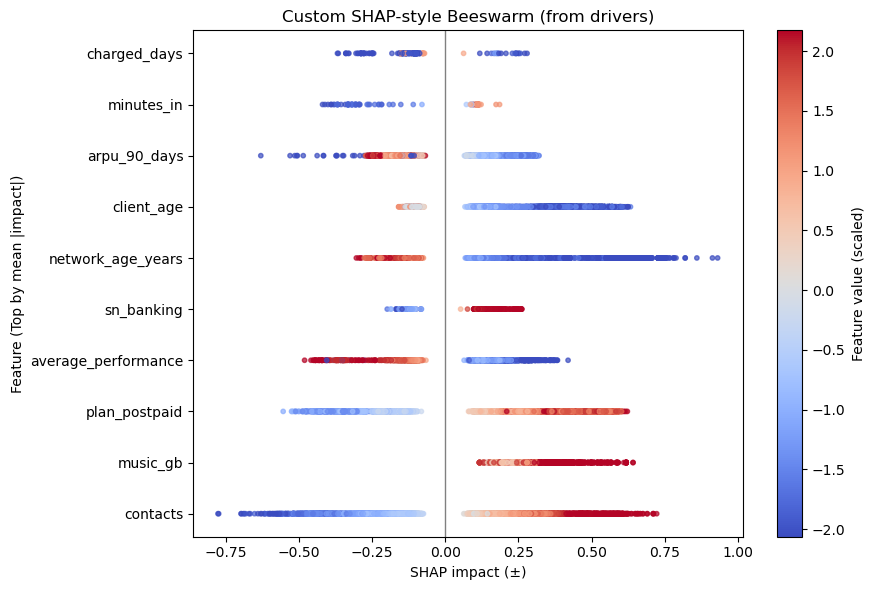

In [18]:
plot_beeswarm_from_drivers(df, top=10)

## Exploratory Data Analysis Conclusions

### Analysis Summary

This notebook presents an exploratory data analysis focused on campaign candidates, utilizing advanced machine learning model explainability techniques through SHAP (SHapley Additive exPlanations) values. The analyzed dataset contains **candidate information** with their respective success probabilities and detailed explanatory factors.

### SHAP Data Context

The analyzed data contains pre-calculated SHAP explanations that enable understanding of each feature's individual contribution to model predictions. These SHAP values provide:

**Data Characteristics:**
- **Structure**: Each record contains nested drivers with feature, value, and impact
- **Interpretability**: SHAP values allow explaining decisions at individual level
- **Granularity**: Analysis at both aggregated and individual characteristic levels
- **Directionality**: Positive and negative impacts indicating prediction influence

### Main Findings

**1. Data Structure and Dimensions**
- The dataset contains **multiple candidate records** with complex structure including nested drivers
- Each record includes a 'proba' column with probabilities and a 'drivers' column with SHAP explanations
- Drivers are structured as dictionaries with 'feature', 'value', and 'impact' for each characteristic

**2. Model Probability Distribution**
- The **probability histogram** reveals the predictive model's confidence distribution
- This distribution indicates how confident the model is in its predictions for different candidates
- The distribution shape suggests the underlying model's behavior and calibration

**3. Feature Importance Ranking (Bar Chart)**
The analysis of the "Average absolute SHAP impact by feature" chart reveals critical insights:

- **`plan_postpaid`** dominates as the most influential characteristic with an average absolute impact of ~0.30
- **`music_gb`** and **`network_age_years`** follow as second and third most important factors (~0.29 and ~0.27 respectively)
- **Clear hierarchy**: A well-defined gradation exists from most to least influential characteristics
- **Predictive power concentration**: The top 5 characteristics (**plan_postpaid, music_gb, network_age_years, contacts, client_age**) concentrate most of the model's explanatory power
- **Operational vs. demographic characteristics**: A mix of operational variables (plan type, usage patterns) and demographic ones (age, tenure) is observed

**4. Individual Impact Patterns (Beeswarm Analysis)**
The beeswarm chart "Custom SHAP-style Beeswarm (from drivers)" provides granular insights:

**Feature-Specific Patterns:**
- **`plan_postpaid`**: Shows mostly positive impacts (red) for high values, suggesting that having a postpaid plan significantly increases success probability
- **`music_gb`**: Presents an interesting pattern with negative impacts concentrated for low/medium values (blue) and positive impacts for high values (red)
- **`network_age_years`**: Exhibits negative impacts for medium values (red on left side) and positive impacts for higher values (blue on right side)
- **`contacts`**: Shows a bimodal distribution with both negative and positive impacts, suggesting that contact frequency can be both beneficial and detrimental depending on context
- **`client_age`**: Presents mostly positive impacts across a wide age range, with some negative values for specific ages

**Distribution Insights:**
- **Observation density**: Point concentration reveals the most common value ranges for each characteristic
- **Impact variability**: Characteristics show different levels of variability in their individual effects
- **Value-impact correlations**: Colors (coolwarm scale) indicate how different characteristic values correlate with specific impact directions

### Analysis-Specific Insights

**Characteristic Behavior:**
- The model shows **prediction heterogeneity**, evidenced by variability in SHAP values
- A **clear hierarchization** of factors exists, suggesting consistent patterns in the data
- Dispersion patterns in the beeswarm indicate **non-linear relationships** between characteristics and predictions

**Explanation Quality:**
- The presence of both positive and negative SHAP values indicates a **balanced analysis**
- Impact variability suggests **adaptation to individual contexts**
- Consistency in characteristic rankings indicates **stability in relative importance**

**Integrated Visual Analysis:**
- **Visualization complementarity**: The bar chart provides global ranking while the beeswarm reveals individual patterns
- **Metric coherence**: Importance rankings remain consistent between both visualizations
- **Insight granularity**: The combination allows understanding both relative importance and specific influence mechanisms

### Strategic Implications

**For Decision Making:**
1. **Resource prioritization**: Focus efforts on the highest impact characteristics identified (plan_postpaid, music_gb, network_age_years)
2. **Segmentation**: Beeswarm patterns allow identifying candidate profiles with similar behaviors
3. **Optimization**: Characteristics with higher impact variability offer targeted improvement opportunities
4. **Differentiated strategies**: Analysis of specific patterns enables developing targeted strategies for different segments

**For Model Development:**
1. **Feature validation**: Top characteristics require cross-validation with domain experts
2. **Feature engineering**: Opportunities to create composite features based on observed patterns
3. **Monitoring**: Establish alerts for changes in characteristic importance distribution
4. **Refinement**: Consider optimization of characteristics with identified complex patterns

**Specific Operational Insights:**
- **Postpaid Plan**: The dominance of this characteristic suggests plan type is a critical success predictor
- **Music Consumption**: Data usage patterns for music indicate relevant engagement behaviors
- **Customer Tenure**: Network age shows complex patterns requiring detailed analysis
- **Contact Frequency**: The bimodal nature suggests need to optimize contact strategies

### Limitations and Considerations

- **Contextual interpretation**: Technical results require validation with specific domain knowledge
- **Temporal stability**: Observed patterns may change over time and require continuous monitoring
- **Generalization**: Insights are specific to this particular dataset
- **Visual resolution**: Interpretation of complex beeswarm patterns may require additional analysis for specific cases
- **Causality**: SHAP values indicate correlation but not necessarily causation

### Future Analysis Recommendations

1. **Sensitivity analysis**: Evaluate ranking stability of importance with different subsamples
2. **Cross-validation**: Confirm SHAP patterns are consistent with different configurations
3. **Interaction analysis**: Explore interactions between the most important identified characteristics
4. **Benchmarking**: Compare these results with alternative importance analysis methods
5. **Feature-specific deep-dives**: Conduct detailed analysis of top 5 characteristics to understand underlying mechanisms
6. **Beeswarm pattern validation**: Confirm observed insights with specific cohort analysis
7. **Temporal analysis**: Study the evolution of these patterns over time
8. **Advanced segmentation**: Develop customer profiles based on identified SHAP patterns

This exploratory analysis establishes a **solid foundation for data understanding**, providing actionable insights that combine analytical rigor with practical applicability in the context of campaign candidate evaluation. SHAP visualizations reveal both global patterns and specific individual behaviors, creating a robust foundation for developing targeting strategies and campaign optimization.